# PatchTST Energy Forecasting
This notebook adds a PatchTST transformer model for next 1-hour energy prediction
with CRAC temperature what-if scenarios (+/- 2°C).

## 1. Load engineered features
Assumes output from feature_engineering.ipynb as a flat CSV.

In [4]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# Load precomputed energy forecasting tensors
X = np.load("X_Energy.npy")   # (N, 30, 7)
y = np.load("Y_Energy.npy")   # (N, 12)

print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (7643, 30, 7)
y shape: (7643, 12)


## 3. Dataset & windowing

In [5]:


class EnergyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = EnergyDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)


## 4. Infer dimensions from tensors

In [7]:
# Infer dimensions directly from tensors
SEQ_LEN = X.shape[1]
N_FEATURES = X.shape[2]
HORIZON = y.shape[1]

print("SEQ_LEN:", SEQ_LEN)
print("N_FEATURES:", N_FEATURES)
print("HORIZON:", HORIZON)


SEQ_LEN: 30
N_FEATURES: 7
HORIZON: 12


## 5. PatchTST model definition

In [8]:
import torch.nn as nn

class PatchTST(nn.Module):
    def __init__(self, n_features, horizon, d_model=64, n_heads=4, n_layers=2):
        super().__init__()

        self.input_proj = nn.Linear(n_features, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        # x: (batch, seq_len, features)
        x = self.input_proj(x)
        x = self.encoder(x)
        x = x.mean(dim=1)      # temporal pooling
        return self.head(x)


## 6. Model, optimizer, loss

In [9]:
model = PatchTST(
    n_features=N_FEATURES,
    horizon=HORIZON
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


## 7. Training loop


In [10]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss / len(loader):.4f}")


Epoch 1/10 - Loss: 0.0905
Epoch 2/10 - Loss: 0.0857
Epoch 3/10 - Loss: 0.0857
Epoch 4/10 - Loss: 0.0852
Epoch 5/10 - Loss: 0.0850
Epoch 6/10 - Loss: 0.0849
Epoch 7/10 - Loss: 0.0846
Epoch 8/10 - Loss: 0.0846
Epoch 9/10 - Loss: 0.0844
Epoch 10/10 - Loss: 0.0843


In [11]:
# CRAC proxy feature index
CRAC_IDX = 3  # inlet_temp_c

def apply_crac_scenario(X, delta):
    X_s = X.copy()
    X_s[:, :, CRAC_IDX] += delta
    return X_s

model.eval()
with torch.no_grad():
    baseline = model(torch.tensor(X[-1:], dtype=torch.float32)).numpy()
    plus_2 = model(
        torch.tensor(apply_crac_scenario(X, +2)[-1:], dtype=torch.float32)
    ).numpy()
    minus_2 = model(
        torch.tensor(apply_crac_scenario(X, -2)[-1:], dtype=torch.float32)
    ).numpy()

baseline, plus_2, minus_2


(array([[0.5003965 , 0.49586204, 0.5064735 , 0.5273015 , 0.54729104,
         0.51347184, 0.5514882 , 0.5072541 , 0.4740909 , 0.4874668 ,
         0.5583606 , 0.52671796]], dtype=float32),
 array([[0.502265  , 0.49655762, 0.5145159 , 0.5255153 , 0.5525238 ,
         0.5149091 , 0.55189735, 0.50938416, 0.47324723, 0.49287444,
         0.5555757 , 0.53101313]], dtype=float32),
 array([[0.5010605 , 0.49458227, 0.4945642 , 0.5256439 , 0.5390652 ,
         0.507886  , 0.5514919 , 0.5042288 , 0.47628847, 0.47426352,
         0.56386286, 0.5203163 ]], dtype=float32))

In [12]:
xb, yb = next(iter(loader))
print(xb.shape)  # (batch, SEQ_LEN, N_FEATURES)
print(yb.shape)  # (batch, HORIZON)


torch.Size([32, 30, 7])
torch.Size([32, 12])


In [13]:
import numpy as np

def summarize(pred):
    return {
        "mean": pred.mean(),
        "sum": pred.sum(),
        "peak": pred.max()
    }

summary = {
    "baseline": summarize(baseline[0]),
    "crac_plus_2": summarize(plus_2[0]),
    "crac_minus_2": summarize(minus_2[0])
}

summary


{'baseline': {'mean': np.float32(0.51634794),
  'sum': np.float32(6.1961756),
  'peak': np.float32(0.5583606)},
 'crac_plus_2': {'mean': np.float32(0.51835656),
  'sum': np.float32(6.2202787),
  'peak': np.float32(0.5555757)},
 'crac_minus_2': {'mean': np.float32(0.5127711),
  'sum': np.float32(6.1532536),
  'peak': np.float32(0.56386286)}}

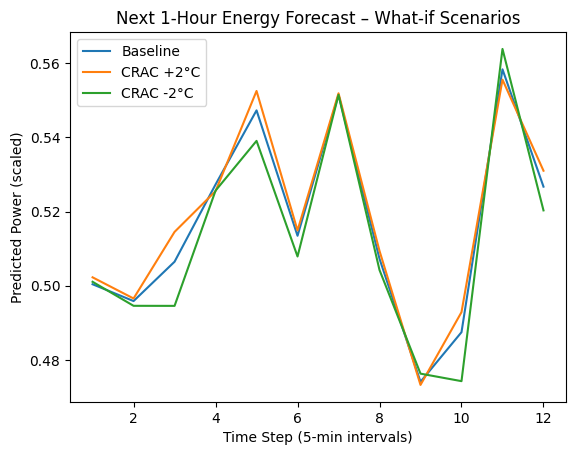

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Extract 1D arrays
t = np.arange(1, baseline.shape[1] + 1)

plt.figure()
plt.plot(t, baseline[0], label="Baseline")
plt.plot(t, plus_2[0], label="CRAC +2°C")
plt.plot(t, minus_2[0], label="CRAC -2°C")

plt.xlabel("Time Step (5-min intervals)")
plt.ylabel("Predicted Power (scaled)")
plt.title("Next 1-Hour Energy Forecast – What-if Scenarios")
plt.legend()
plt.show()


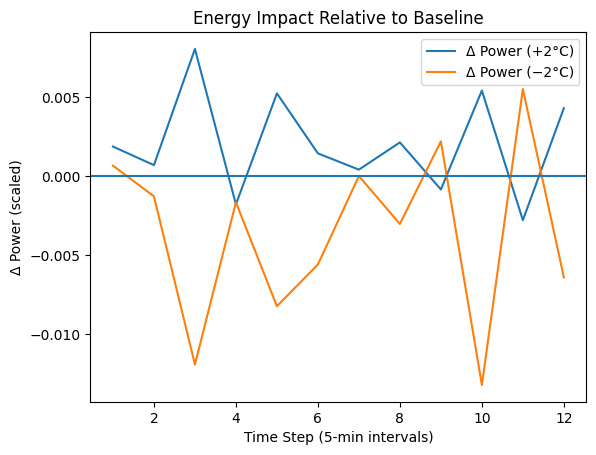

In [15]:
plt.figure()
plt.plot(t, plus_2[0] - baseline[0], label="Δ Power (+2°C)")
plt.plot(t, minus_2[0] - baseline[0], label="Δ Power (−2°C)")
plt.axhline(0)

plt.xlabel("Time Step (5-min intervals)")
plt.ylabel("Δ Power (scaled)")
plt.title("Energy Impact Relative to Baseline")
plt.legend()
plt.show()


In [16]:
kwh_saving = (baseline - plus_2).sum() * (5/60)


In [19]:
print( kwh_saving)

-0.0020086444
